In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

In [48]:
# ============================================================
# 1. LOAD DATA
# ============================================================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [4]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


Taking a deeper look at the features

In [15]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Histogram for each numeric column
# numeric_cols = train.select_dtypes(include=[np.number]).columns
# for col in numeric_cols:
#     plt.figure(figsize=(8, 3))
#     plt.hist(train[col].dropna(), bins=50)
#     plt.title(col)
#     plt.show()

Many of the numerical features appear to be heavily right skewed. There also appears to be a lot of blank space, most likely meaning we can expect some outliers. We will apply log for these features to avoid having outliers heavily affect our model.

In [13]:
cat_cols = train.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    print(f"\n{col}:")
    print(train[col].value_counts())


HomePlanet:
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64

CryoSleep:
CryoSleep
False    5439
True     3037
Name: count, dtype: int64

Destination:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

VIP:
VIP
False    8291
True      199
Name: count, dtype: int64

Transported:
Transported
True     4378
False    4315
Name: count, dtype: int64

Cabin_Deck:
Cabin_Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

Cabin_Side:
Cabin_Side
S    4288
P    4206
Name: count, dtype: int64


C:\Users\jeffj\AppData\Local\Temp\ipykernel_2356\3014677902.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object', 'bool']).columns


In [16]:
199/(8291 + 199)

0.023439340400471142

VIP appears to be heavily weighted to have 0.023% VIP members, so it is unlikely to be helpful. Cabin contains three different values in one string. We will need to split it apart.

Now directly plotting each feature against the target:

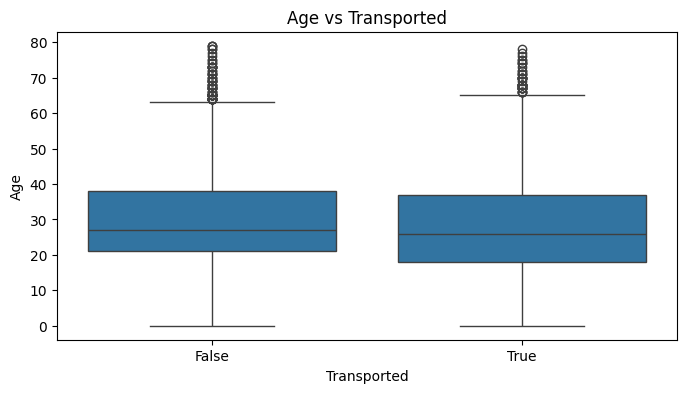

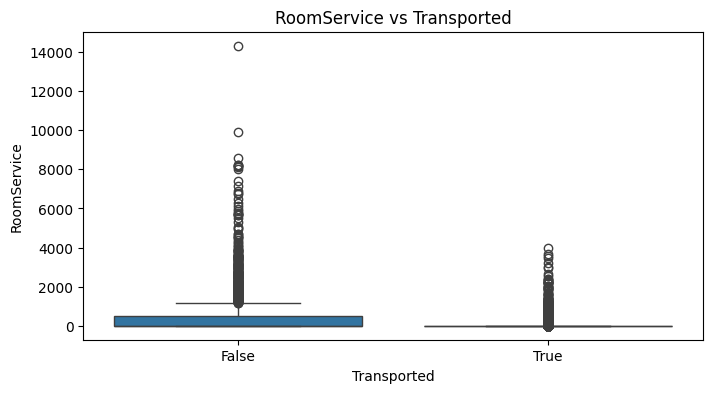

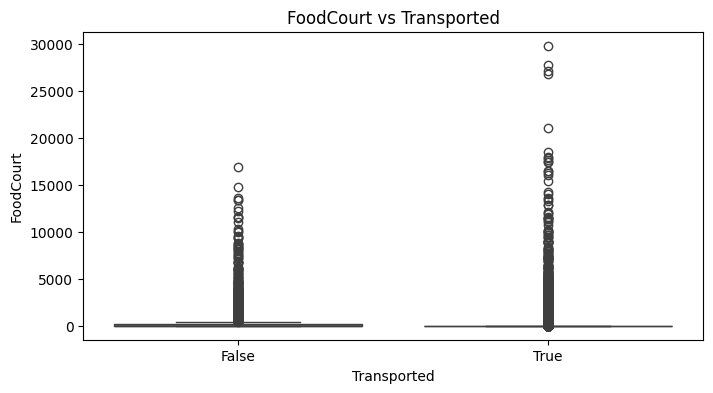

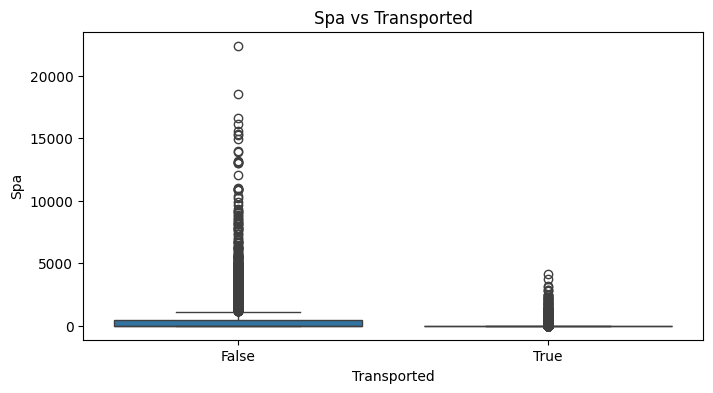

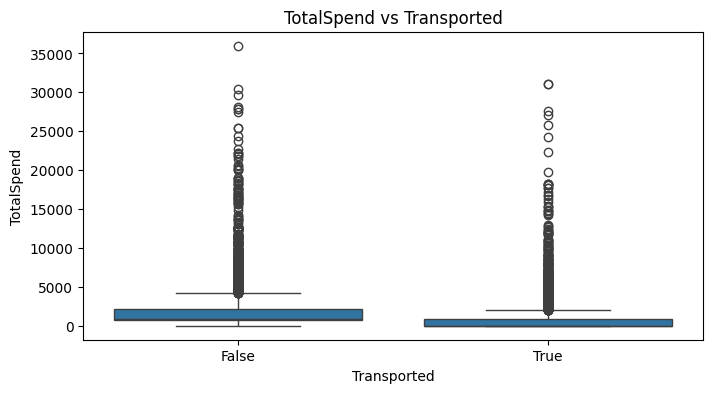

In [17]:
for col in ['Age', 'RoomService', 'FoodCourt', 'Spa', 'TotalSpend']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Transported', y=col, data=train)
    plt.title(f'{col} vs Transported')
    plt.show()

There seems to be a different median for the total spent vs transported, so we'll look for a connection there. The amount transported seems to share the same median for age, so there may not be much to infer there.

now looking at categorical features

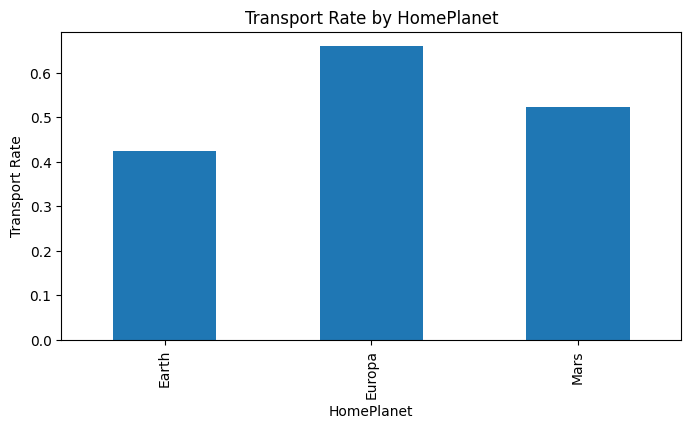

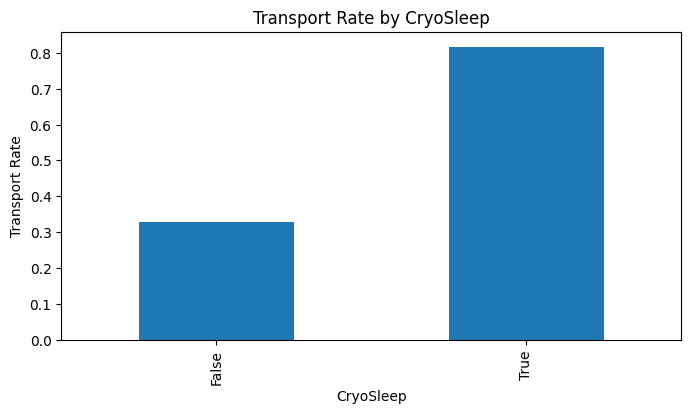

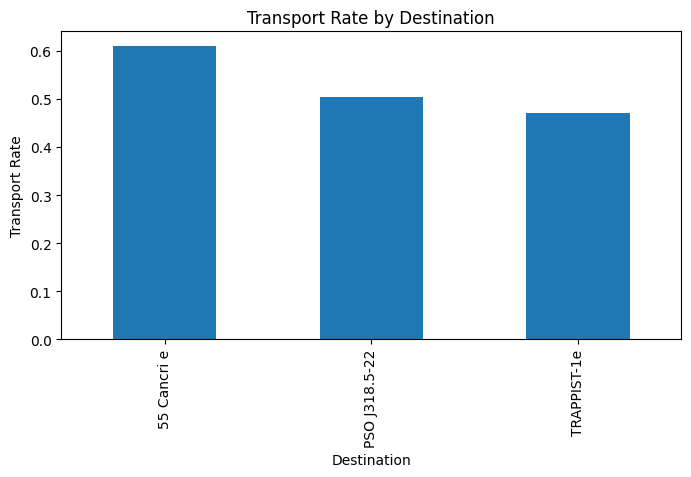

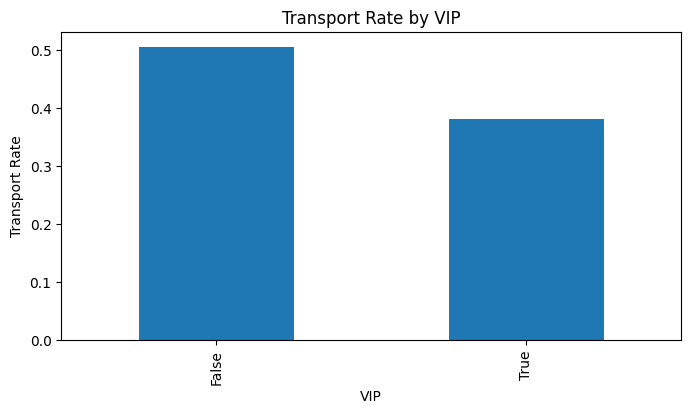

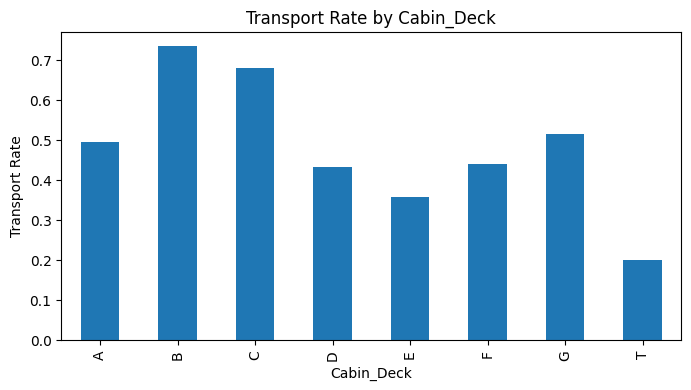

In [18]:
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck']:
    plt.figure(figsize=(8, 4))
    rates = train.groupby(col)['Transported'].mean()
    rates.plot(kind='bar')
    plt.ylabel('Transport Rate')
    plt.title(f'Transport Rate by {col}')
    plt.show()

We see some features stand out with a high transport rate: Europa has a high rate, being in Cyrostatis has a high rate of transport, and being in cabin B or C has a high transport rate. There is a high chance these features will affect whether or not someone is transported.

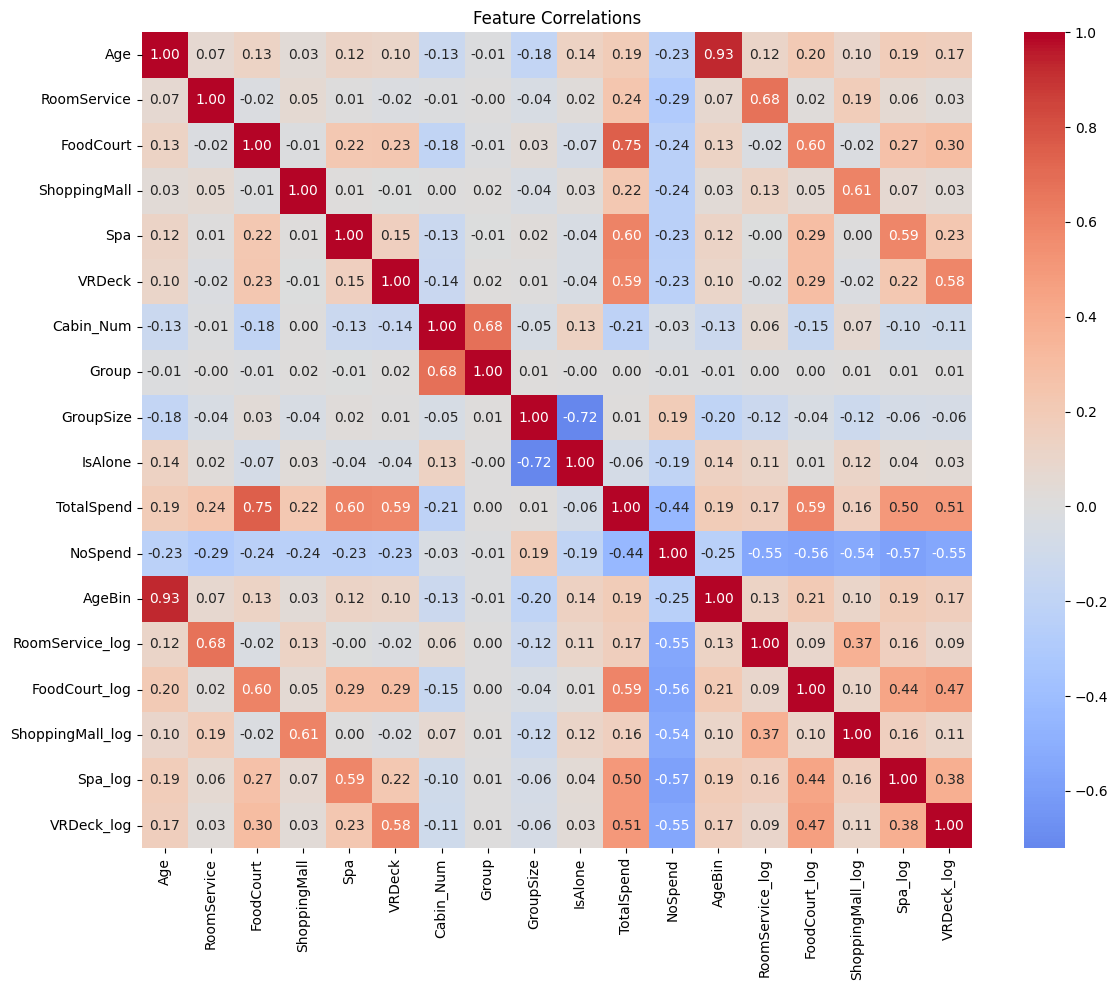

In [19]:
plt.figure(figsize=(12, 10))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

There are some correlation between being alone and being in a group, and the total money spent vs the money spent on anemities, but there isn't any unqiue feature that stands out.

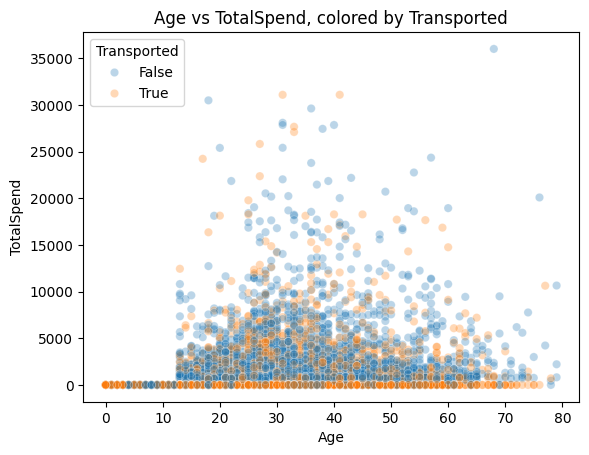

In [20]:
sns.scatterplot(x='Age', y='TotalSpend', hue='Transported', data=train, alpha=0.3)
plt.title('Age vs TotalSpend, colored by Transported')
plt.show()

Even with low correlation values, knowing that young people tend to spend differently than old people, there could be a connection here. But the amount of those who spent money didn't form any clusters with the people who were transported. 

In [28]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================
 
def engineer_features(df):
    df = df.copy()
 
    # --- Split Cabin into Deck, Num, Side ---
    # Cabin looks like "B/0/P" meaning Deck B, Room 0, Port side
    # Each part could be useful: deck = which floor, side = port vs starboard
    df['Cabin_Deck'] = df['Cabin'].str.split('/').str[0]
    df['Cabin_Num'] = df['Cabin'].str.split('/').str[1].astype(float)
    df['Cabin_Side'] = df['Cabin'].str.split('/').str[2]
 
    # --- Extract group info from PassengerId ---
    # PassengerId is like "0001_01" — first part is the group
    # People in the same group are traveling together
    df['Group'] = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
 
    # --- Total spending ---
    # If someone spent nothing, they might have been in CryoSleep
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['NoSpend'] = (df['TotalSpend'] == 0).astype(int)
 
    # --- Age bins ---
    # Children and elderly may have different transport rates
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100],
                          labels=[0, 1, 2, 3, 4]).astype(float)
 
    # --- Log transform spending ---
    # Spending columns are heavily right-skewed (most people spend little,
    # a few spend a lot). Log transform compresses the scale so that
    # outliers don't dominate.
    for col in spend_cols:
        df[f'{col}_log'] = np.log1p(df[col])  # log1p = log(1+x), handles zeros
 
    # --- Drop columns we can't use ---
    df = df.drop(columns=['PassengerId', 'Cabin', 'Name'])
 
    return df
 
train_feature = engineer_features(train)
test_ids = test['PassengerId']  # save for submission before dropping
test_feature = engineer_features(test)
pd.set_option('display.max_columns', None)
train_feature.head(5)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Group,GroupSize,IsAlone,TotalSpend,NoSpend,AgeBin,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,VRDeck_log
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1,1,1,0.0,1,3.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,2,1,1,736.0,0,2.0,4.700480,2.302585,3.258097,6.309918,3.806662
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,3,2,0,10383.0,0,4.0,3.784190,8.182280,0.000000,8.812248,3.912023
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,3,2,0,5176.0,0,3.0,0.000000,7.157735,5.918894,8.110728,5.267858
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,4,1,1,1091.0,0,1.0,5.717028,4.262680,5.023881,6.338594,1.098612


Cabin is in the form of  deck/num/side, where side can be either P for Port or S for Starboard. We needed to split it into three columns for the model to read each element. 

PassengerId = "0001_01" — the first part is a group number, the second is the person's position within the group. We needed to split it, and adding a variable, if the person is traveling alone may be a factor in if the person could be transported.

Total spending is worth checking, and agebins may give a more categorical view vs a linear relationship with transported people.

In [34]:
# ============================================================
# 3. HANDLE MISSING VALUES & ENCODE CATEGORICALS
# ============================================================
 
# Fill numeric columns with the median (middle value)
# Why median instead of mean? Median isn't affected by outliers.
# If most people are age 25-35 but one person is 300 (data error),
# the mean shifts a lot but the median doesn't.
numeric_cols = train_feature.select_dtypes(include=[np.number]).columns.tolist()

 
for col in numeric_cols:
    median_val = train_feature[col].median()
    train_feature[col] = train_feature[col].fillna(median_val)
    test_feature[col] = test_feature[col].fillna(median_val)
 
# Fill categorical columns with the mode (most common value)
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP',
            'Cabin_Deck', 'Cabin_Side']
 
for col in cat_cols:
    mode_val = train_feature[col].mode()[0]
    train_feature[col] = train_feature[col].fillna(mode_val)
    test_feature[col] = test_feature[col].fillna(mode_val)
 
# Convert True/False strings to 0/1
for col in ['CryoSleep', 'VIP']:
    train_feature[col] = train_feature[col].astype(bool).astype(int)
    test_feature[col] = test_feature[col].astype(bool).astype(int)
 
# Label encode categorical strings
# This turns "Earth"=0, "Europa"=1, "Mars"=2 etc.
# LightGBM can handle these as categories directly
from sklearn.preprocessing import LabelEncoder
for col in ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']:
    le = LabelEncoder()
    le.fit(pd.concat([train_feature[col], test_feature[col]]))
    train_feature[col] = le.transform(train_feature[col])
    test_feature[col] = le.transform(test_feature[col])
 
# Separate target
y = train_feature['Transported'].astype(int)
X = train_feature.drop(columns=['Transported'])
 
print(f"\nFinal features: {X.columns.tolist()}")
print(f"Feature count: {X.shape[1]}")
print(f"Target balance: {y.value_counts().to_dict()}")
print(f"Target values: {y.head()}")


Final features: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_Deck', 'Cabin_Num', 'Cabin_Side', 'Group', 'GroupSize', 'IsAlone', 'TotalSpend', 'NoSpend', 'AgeBin', 'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log', 'VRDeck_log']
Feature count: 24
Target balance: {1: 4378, 0: 4315}
Target values: 0    0
1    1
2    0
3    0
4    1
Name: Transported, dtype: int64


Other than filling in empty values, I replaced the true/false values with 1 and 0, since it would be easier for most models to read over a boolean.

In [38]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# ============================================================
# 4. BASELINE MODEL — DEFAULT HYPERPARAMETERS
# ============================================================
# Always start with defaults so you know what you're improving from.
 
print("\n--- Baseline (default hyperparameters) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = []
 
for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y)):
    model = LGBMClassifier(random_state=42, verbosity=-1)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    preds = model.predict(X.iloc[va_idx])
    score = accuracy_score(y.iloc[va_idx], preds)
    baseline_scores.append(score)
    print(f"  Fold {fold+1}: {score:.4f}")
 
print(f"  Baseline CV accuracy: {np.mean(baseline_scores):.4f}")


--- Baseline (default hyperparameters) ---
  Fold 1: 0.8062
  Fold 2: 0.8028
  Fold 3: 0.8177
  Fold 4: 0.8107
  Fold 5: 0.8021
  Baseline CV accuracy: 0.8079


This is a pretty good baseline, based on our features. The model appears to make generally decent predictions.

In [37]:
# ============================================================
# 5. HYPERPARAMETER TUNING
# ============================================================
#
# METHOD 1: GRID SEARCH
# =====================
# Tries every combination of parameters you specify.
# Pro: Guaranteed to find the best combo in your grid.
# Con: Slow — if you have 3 params with 4 values each, that's
#      4 x 4 x 4 = 64 combinations, each trained 5 times (CV) = 320 fits.
#
# Start with a coarse grid (few, spread-out values) to find the
# right neighborhood, then do a fine grid around the best values.
 
print("\n--- Grid Search (coarse) ---")
 
coarse_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
}
 
grid_search = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    param_grid=coarse_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    verbose=1
)
 
grid_search.fit(X, y)
print(f"  Best params: {grid_search.best_params_}")
print(f"  Best CV accuracy: {grid_search.best_score_:.4f}")
 
# Now do a fine grid around those best values
# For example, if coarse search found max_depth=6, try 5, 6, 7
best = grid_search.best_params_
 
print("\n--- Grid Search (fine) ---")
 
fine_grid = {
    'n_estimators': [best['n_estimators'] - 100,
                     best['n_estimators'],
                     best['n_estimators'] + 100],
    'max_depth': [max(1, best['max_depth'] - 1),
                  best['max_depth'],
                  best['max_depth'] + 1],
    'learning_rate': [best['learning_rate'] / 2,
                      best['learning_rate'],
                      best['learning_rate'] * 2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}
 
fine_search = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    param_grid=fine_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
 
fine_search.fit(X, y)
print(f"  Best params: {fine_search.best_params_}")
print(f"  Best CV accuracy: {fine_search.best_score_:.4f}")


--- Grid Search (coarse) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
  Best CV accuracy: 0.8118

--- Grid Search (fine) ---
Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\jeffj\OneDrive\Desktop\AWS S3 files\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
405 fits failed out of a total of 1215.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
405 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jeffj\OneDrive\Desktop\AWS S3 files\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jeffj\OneDrive\Desktop\AWS S3 files\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
        in

  Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
  Best CV accuracy: 0.8139


With a best CV accuracy of 0.8139, it appears the default parameters is the better model. We will do one final train with the best parameters here to confirm if it is worse.

In [40]:
# ============================================================
# 6. TRAIN FINAL MODEL WITH BEST PARAMETERS
# ============================================================
 
best_params = fine_search.best_params_
print(f"\n--- Final model with: {best_params} ---")
 
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_feature))
 
for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y)):
    model = LGBMClassifier(
        **best_params,
        random_state=42,
        verbosity=-1
    )
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
 
    oof_preds[va_idx] = model.predict(X.iloc[va_idx])
    test_preds += model.predict_proba(test_feature)[:, 1] / 5
 
    score = accuracy_score(y.iloc[va_idx], oof_preds[va_idx])
    print(f"  Fold {fold+1}: {score:.4f}")
 
print(f"  Final CV accuracy: {accuracy_score(y, oof_preds):.4f}")


--- Final model with: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7} ---
  Fold 1: 0.8062
  Fold 2: 0.8039
  Fold 3: 0.8223
  Fold 4: 0.8326
  Fold 5: 0.8044
  Final CV accuracy: 0.8139


With our model complete, lets evaulate our features.

In [42]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# ============================================================
# 4. BASELINE MODEL — DEFAULT HYPERPARAMETERS
# ============================================================
# Always start with defaults so you know what you're improving from.
 
print("\n--- Baseline (default hyperparameters) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = []
 
for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y)):
    model = LGBMClassifier(random_state=42, verbosity=-1)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    preds = model.predict(X.iloc[va_idx])
    score = accuracy_score(y.iloc[va_idx], preds)
    baseline_scores.append(score)
    print(f"  Fold {fold+1}: {score:.4f}")
 
print(f"  Baseline CV accuracy: {np.mean(baseline_scores):.4f}")


--- Baseline (default hyperparameters) ---
  Fold 1: 0.8062
  Fold 2: 0.8028
  Fold 3: 0.8177
  Fold 4: 0.8107
  Fold 5: 0.8021
  Baseline CV accuracy: 0.8079


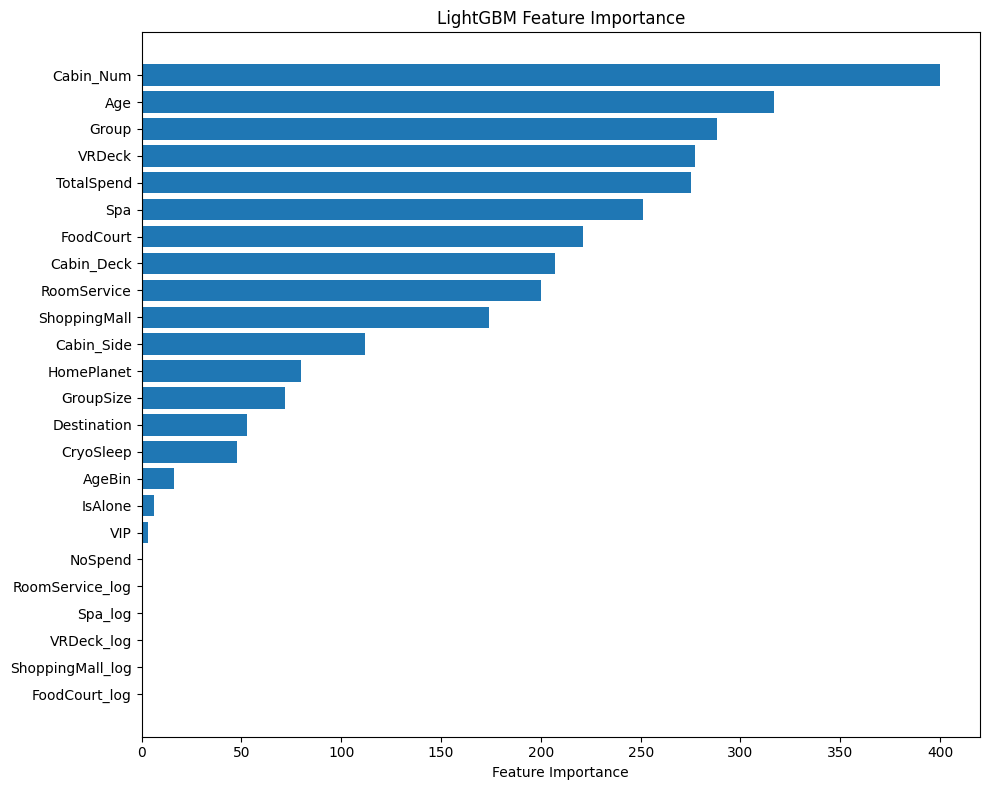

In [43]:
# ============================================================
# 7. FEATURE IMPORTANCE
# ============================================================
 
importance = model.feature_importances_
feat_names = X.columns.tolist()
 
sorted_idx = np.argsort(importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feat_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('LightGBM Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

Many of the spending logorithms were unhelpful and can be removed. Cabin number is quite dominant, so it might be worth exploring it further.

In [63]:


X_drop = X.drop(columns=['FoodCourt_log', 'ShoppingMall_log', 'VRDeck_log', 'Spa_log','RoomService_log', 'NoSpend'])

print(max(train_feature['Cabin_Num']))
X_drop['CabinNumBin'] = pd.cut(train_feature['Cabin_Num'], bins=[0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000],
                          labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]).astype(float)

1894.0


In [64]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# ============================================================
# 4. BASELINE MODEL — DEFAULT HYPERPARAMETERS
# ============================================================
# Always start with defaults so you know what you're improving from.
 
print("\n--- Baseline (default hyperparameters) ---")
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = []
 
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_drop, y)):
    model = LGBMClassifier(random_state=42, verbosity=-1)
    model.fit(X_drop.iloc[tr_idx], y.iloc[tr_idx])
    preds = model.predict(X_drop.iloc[va_idx])
    score = accuracy_score(y.iloc[va_idx], preds)
    baseline_scores.append(score)
    print(f"  Fold {fold+1}: {score:.4f}")
 
print(f"  Baseline CV accuracy: {np.mean(baseline_scores):.4f}")


--- Baseline (default hyperparameters) ---
  Fold 1: 0.8079
  Fold 2: 0.8114
  Fold 3: 0.8154
  Fold 4: 0.8216
  Fold 5: 0.8038
  Baseline CV accuracy: 0.8120


Adding bins to the model does not help. I will end with submitting the baseline model.